# <center>**Titanic - Machine Learing from Disaster**<center>

## **1. Xác định bài toán và dữ liệu**

Mục tiêu là dự đoán hành khách có sống sót sau thảm họa Titanic hay không. Đây là bài toán phân loại nhị phân: `Survived = 1` là sống sót, `Survived = 0` là không sống sót.

Dữ liệu huấn luyện và kiểm tra được đọc từ thư mục `data` nằm cùng cấp với notebook. Tập kiểm tra không có nhãn `Survived`, vì vậy chỉ dùng để tạo dự đoán sau khi đã đánh giá mô hình trên một tập kiểm định tách riêng từ train.

In [103]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore", category = FutureWarning)
sns.set_theme(style = "whitegrid", palette = "deep")

In [104]:
# Xác lập đường dẫn đến thư mục chứa dữ liệu
DATA_DIR = Path("data")
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

In [105]:
# Tạo một số đặc trưng có thể dùng chung cho train và test
def add_features(data):
    result = data.copy()
    result["FamilySize"] = result["SibSp"].fillna(0) + result["Parch"].fillna(0) + 1
    result["IsAlone"] = (result["FamilySize"] == 1).astype(int)
    result["Title"] = result["Name"].str.extract(r",\s*([^.]*)\.", expand = False).str.strip()
    result["Title"] = result["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    result["Title"] = result["Title"].where(result["Title"].isin(["Mr", "Miss", "Mrs", "Master"]), "Rare")
    result["Deck"] = result["Cabin"].str[0].fillna("Chưa rõ").replace({"T": "Chưa rõ"})
    return result

train_df = add_features(train_df)
test_df = add_features(test_df)

print(f"Kích thước train: {train_df.shape}")
print(f"Kích thước test: {test_df.shape}")

Kích thước train: (891, 16)
Kích thước test: (418, 15)


In [106]:
# Xem xét phân bố dữ liệu
print(f"Tỷ lệ sống sót trong train: {train_df['Survived'].mean():.3f}")
print("Phân bố boong tàu:")
print(train_df["Deck"].value_counts(dropna = False).to_string())

Tỷ lệ sống sót trong train: 0.384
Phân bố boong tàu:
Deck
Chưa rõ    688
C           59
B           47
D           33
E           32
A           15
F           13
G            4


---
## **2. Khảo sát dữ liệu ban đầu**

Trước khi xây dựng mô hình, kiểm tra kích thước, kiểu dữ liệu, một số dòng đầu, thống kê mô tả và số lượng nhãn. Các bước này giúp nhận diện cột định danh, cột phân loại và các giá trị cần xử lý.

In [107]:
print("Kích thước tập huấn luyện:", train_df.shape)
print("Kích thước tập kiểm tra:", test_df.shape)

Kích thước tập huấn luyện: (891, 16)
Kích thước tập kiểm tra: (418, 15)


In [108]:
print("5 dòng đầu tiên của dữ liệu:")
train_df.head()

5 dòng đầu tiên của dữ liệu:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,Chưa rõ
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,Chưa rõ
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,Chưa rõ


In [109]:
# Kiểu dữ liệu
train_df.dtypes.rename("Kiểu dữ liệu").to_frame().T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,Deck
Kiểu dữ liệu,int64,int64,int64,object,object,float64,int64,int64,object,float64,object,object,int64,int64,object,object


In [110]:
print("Thống kê mô tả các biến số:")
train_df.describe().T

Thống kê mô tả các biến số:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
FamilySize,891.0,1.904602,1.613459,1.00,1.0000,1.0000,2.0,11.0000
IsAlone,891.0,0.602694,0.489615,0.00,0.0000,1.0000,1.0,1.0000


In [111]:
print("Phân bố nhãn Survived:")
train_df["Survived"].value_counts().sort_index().rename(index = {0: "Không sống sót", 1: "Sống sót"}).to_frame("Số hành khách")

Phân bố nhãn Survived:


,Số hành khách
Survived,
Không sống sót,549
Sống sót,342


### **2.1. Giá trị thiếu**

So sánh số lượng và tỷ lệ thiếu giữa train và test. `Cabin` và `Age` thường có nhiều giá trị trống; việc điền khuyết sẽ được thực hiện bên trong pipeline sau khi chia fold.

In [112]:
# Dữ liệu thiếu
missing_summary = pd.DataFrame({
    "Số lượng thiếu": train_df.isna().sum(),
    "Tỷ lệ thiếu (%)": train_df.isna().mean().mul(100),
    "Số lượng thiếu ở test": test_df.isna().sum(),
}).sort_values("Tỷ lệ thiếu (%)", ascending = False)

display(missing_summary[missing_summary["Số lượng thiếu"] > 0].round(2))

,Số lượng thiếu,Tỷ lệ thiếu (%),Số lượng thiếu ở test
Cabin,687,77.10,327.0
Age,177,19.87,86.0
Embarked,2,0.22,0.0


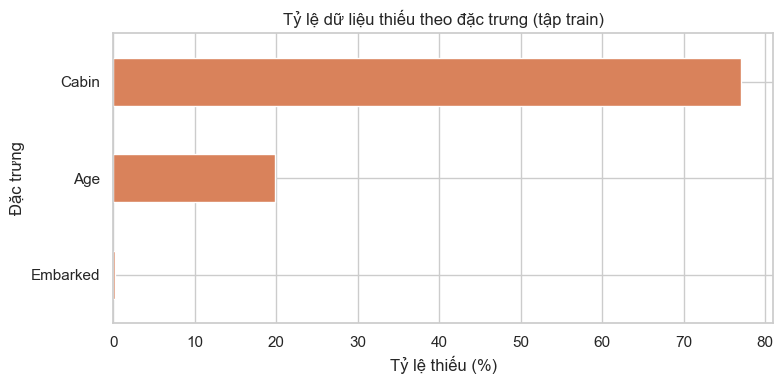

In [113]:
# Vẽ biểu đồ tỷ lệ dữ liệu thiếu
missing_plot = missing_summary[missing_summary["Số lượng thiếu"] > 0]["Tỷ lệ thiếu (%)"]
missing_plot.sort_values().plot(kind = "barh", figsize = (8, 4), color = "#d9825b")

plt.title("Tỷ lệ dữ liệu thiếu theo đặc trưng (tập train)")
plt.xlabel("Tỷ lệ thiếu (%)")
plt.ylabel("Đặc trưng")
plt.tight_layout()
plt.show()

### **2.2. Phân bố biến mục tiêu và tỷ lệ sống sót**

Tập Titanic có mất cân bằng nhãn: số người không sống sót nhiều hơn số người sống sót. Tiếp theo so sánh cả số lượng tuyệt đối lẫn tỷ lệ sống sót theo hạng vé và giới tính.

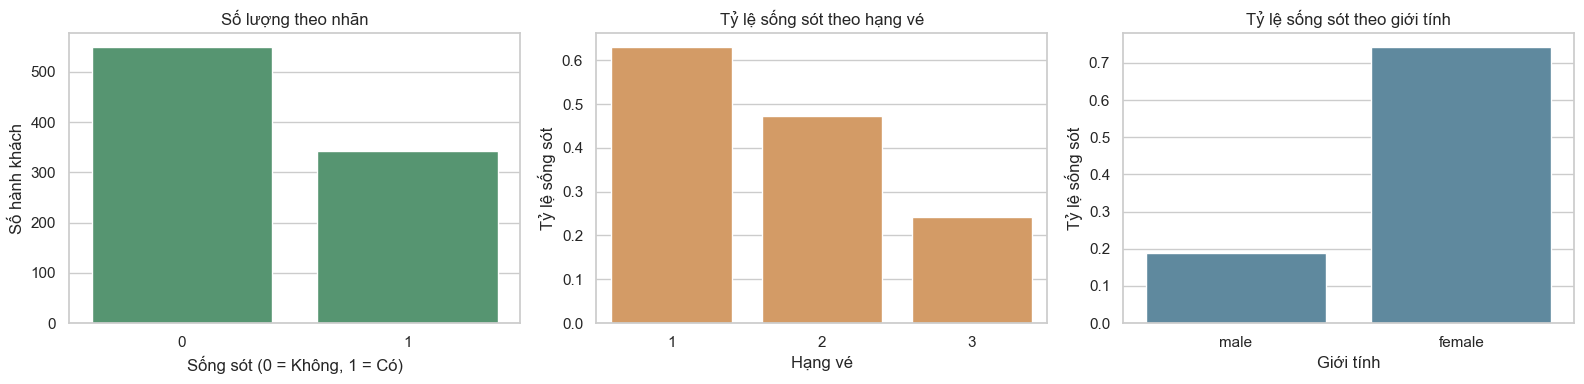

In [114]:
# Phân bố sống sót theo nhãn, hạng vé và giới tính
fig, axes = plt.subplots(1, 3, figsize = (16, 4))

sns.countplot(data = train_df, x = "Survived", ax = axes[0], color = "#4c9f70")
axes[0].set_title("Số lượng theo nhãn")
axes[0].set_xlabel("Sống sót (0 = Không, 1 = Có)")
axes[0].set_ylabel("Số hành khách")

sns.barplot(data = train_df, x = "Pclass", y = "Survived", errorbar = None, ax = axes[1], color = "#e59a54")
axes[1].set_title("Tỷ lệ sống sót theo hạng vé")
axes[1].set_xlabel("Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")

sns.barplot(data = train_df, x = "Sex", y = "Survived", errorbar = None, ax = axes[2], color = "#548ca8")
axes[2].set_title("Tỷ lệ sống sót theo giới tính")
axes[2].set_xlabel("Giới tính")
axes[2].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()

In [115]:
# Tỉ lệ sống sót theo giới tính
pd.crosstab(train_df["Sex"], train_df["Survived"], normalize = "index").rename(columns = {0: "Không sống sót", 1: "Sống sót"}).round(3)

Survived,Không sống sót,Sống sót
Sex,,
female,0.258,0.742
male,0.811,0.189


### **2.3. Phân bố các biến số**

Tuổi và giá vé có giá trị thiếu; các biểu đồ dưới đây bỏ qua giá trị thiếu để mô tả phân bố quan sát được. Giá vé lệch phải nên bổ sung biểu đồ sau biến đổi log để nhìn rõ vùng giá phổ biến.

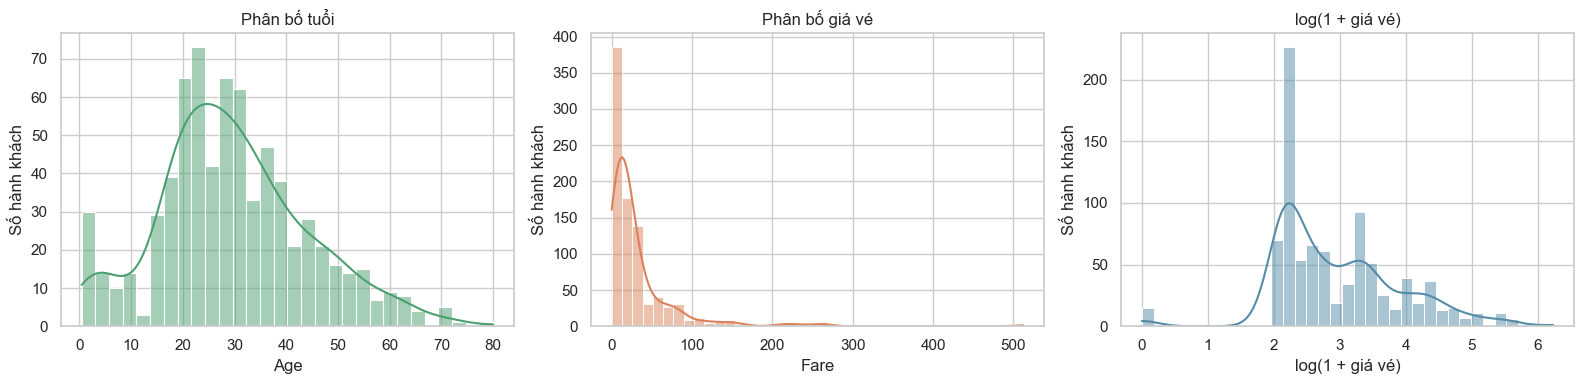

In [116]:
# Phân bố tuổi và giá vé
fig, axes = plt.subplots(1, 3, figsize = (16, 4))

sns.histplot(data = train_df, x = "Age", bins = 30, kde = True, ax = axes[0], color = "#4c9f70")
axes[0].set_title("Phân bố tuổi")
sns.histplot(data = train_df, x = "Fare", bins = 40, kde = True, ax = axes[1], color = "#d9825b")
axes[1].set_title("Phân bố giá vé")
sns.histplot(np.log1p(train_df["Fare"].dropna()), bins = 35, kde = True, ax = axes[2], color = "#548ca8")
axes[2].set_title("log(1 + giá vé)")
axes[2].set_xlabel("log(1 + giá vé)")
for axis in axes:
    axis.set_ylabel("Số hành khách")
    
plt.tight_layout()
plt.show()

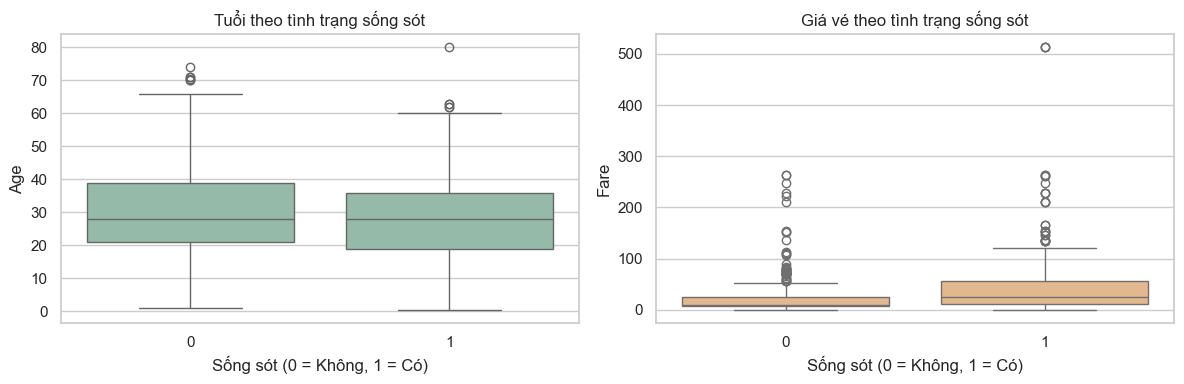

In [117]:
# Phân bố tuổi và giá vé theo tình trạng sống sót
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.boxplot(data = train_df, x = "Survived", y = "Age", ax = axes[0], color = "#8fc0a9")
axes[0].set_title("Tuổi theo tình trạng sống sót")
axes[0].set_xlabel("Sống sót (0 = Không, 1 = Có)")
sns.boxplot(data = train_df, x = "Survived", y = "Fare", ax = axes[1], color = "#f2b880")
axes[1].set_title("Giá vé theo tình trạng sống sót")
axes[1].set_xlabel("Sống sót (0 = Không, 1 = Có)")

plt.tight_layout()
plt.show()

### **2.4. Đặc trưng phân loại và cấu trúc gia đình**

Danh xưng trong tên, điểm lên tàu, boong tàu và quy mô gia đình cung cấp thêm góc nhìn về nhóm hành khách. Một số nhóm nhỏ có ít quan sát, vì vậy tỷ lệ ở nhóm đó có thể dao động mạnh.

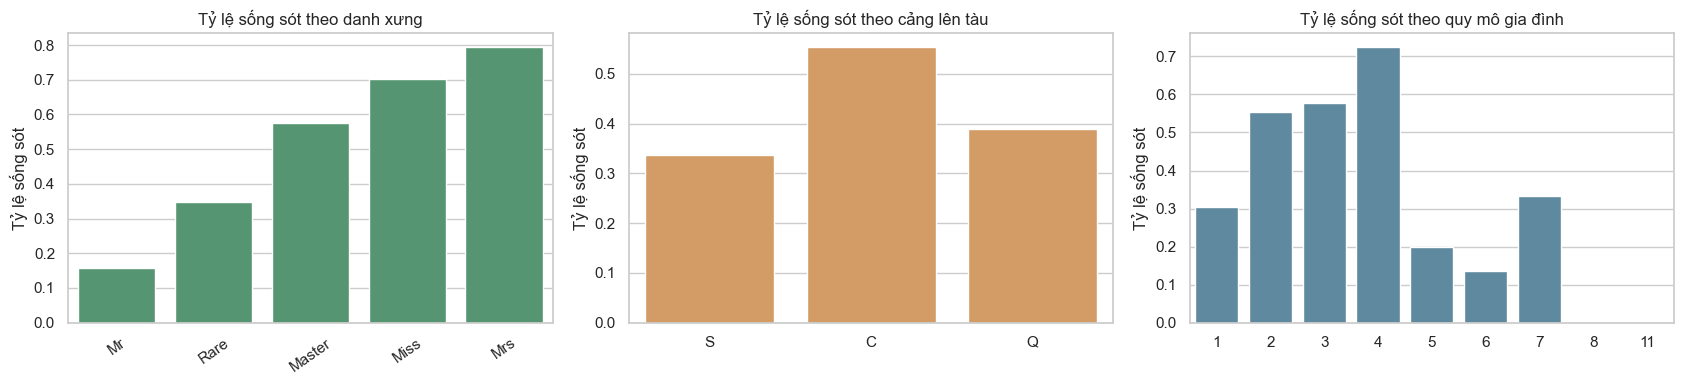

In [118]:
# Phân bố sống sót theo danh xưng, cảng lên tàu và quy mô gia đình
fig, axes = plt.subplots(1, 3, figsize = (17, 4))

sns.barplot(data = train_df, x = "Title", y = "Survived", order = train_df.groupby("Title")["Survived"].mean().sort_values().index, errorbar = None, ax = axes[0], color = "#4c9f70")
axes[0].set_title("Tỷ lệ sống sót theo danh xưng")
axes[0].tick_params(axis = "x", rotation = 35)

sns.barplot(data = train_df, x = "Embarked", y = "Survived", errorbar = None, ax = axes[1], color = "#e59a54")
axes[1].set_title("Tỷ lệ sống sót theo cảng lên tàu")

sns.barplot(data = train_df, x = "FamilySize", y = "Survived", errorbar = None, ax = axes[2], color = "#548ca8")
axes[2].set_title("Tỷ lệ sống sót theo quy mô gia đình")

for axis in axes:
    axis.set_xlabel("")
    axis.set_ylabel("Tỷ lệ sống sót")
    
plt.tight_layout()
plt.show()

In [119]:
print("Thống kê số lượng hành khách và tỷ lệ sống sót theo hạng vé:")
train_df.groupby("Pclass")["Survived"].agg(["count", "mean"]).rename(columns={"count": "Số hành khách", "mean": "Tỷ lệ sống sót"}).round(3)

Thống kê số lượng hành khách và tỷ lệ sống sót theo hạng vé:


,Số hành khách,Tỷ lệ sống sót
Pclass,,
1,216,0.630
2,184,0.473
3,491,0.242


In [120]:
print("Thống kê số lượng hành khách và tỷ lệ sống sót theo kích thước gia đình:")
train_df.groupby("FamilySize")["Survived"].agg(["count", "mean"]).rename(columns = {"count": "Số hành khách", "mean": "Tỷ lệ sống sót"}).round(3)

Thống kê số lượng hành khách và tỷ lệ sống sót theo kích thước gia đình:


,Số hành khách,Tỷ lệ sống sót
FamilySize,,
1,537,0.304
2,161,0.553
3,102,0.578
4,29,0.724
5,15,0.200
6,22,0.136
7,12,0.333
8,6,0.000
11,7,0.000


### **2.5. Ngoại lệ và tương quan**

Dùng quy tắc IQR để đếm các giá trị nằm ngoài khoảng `Q1 - 1.5 × IQR` đến `Q3 + 1.5 × IQR`. Đây là cách đánh dấu điểm cần xem xét, không đồng nghĩa các điểm đó phải bị xóa. Ma trận tương quan bên dưới chỉ dùng biến số.

In [121]:
outlier_rows = []

for column in ["Age", "SibSp", "Parch", "Fare", "FamilySize"]:
    values = train_df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_rows.append({
        "Đặc trưng": column,
        "Q1": q1,
        "Q3": q3,
        "Ngưỡng dưới": lower_bound,
        "Ngưỡng trên": upper_bound,
        "Số ngoại lệ": ((values < lower_bound) | (values > upper_bound)).sum(),
    })

pd.DataFrame(outlier_rows).set_index("Đặc trưng").round(2)

,Q1,Q3,Ngưỡng dưới,Ngưỡng trên,Số ngoại lệ
Đặc trưng,,,,,
Age,20.12,38.0,-6.69,64.81,11
SibSp,0.00,1.0,-1.50,2.50,46
Parch,0.00,0.0,0.00,0.00,213
Fare,7.91,31.0,-26.72,65.63,116
FamilySize,1.00,2.0,-0.50,3.50,91


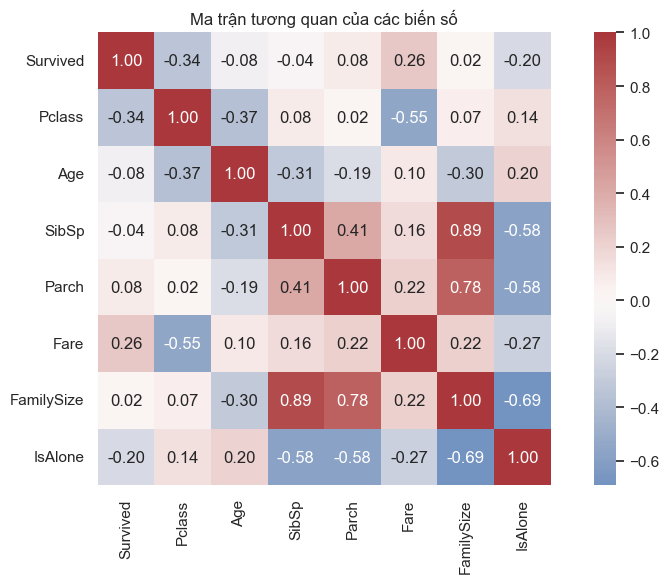

In [122]:
# Ma trận tương quan của các biến số
numeric_for_corr = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]

plt.figure(figsize = (9, 6))
sns.heatmap(train_df[numeric_for_corr].corr(), annot = True, fmt = ".2f", cmap = "vlag", center = 0, square = True)
plt.title("Ma trận tương quan của các biến số")
plt.tight_layout()
plt.show()

---
## **3. Tách tập kiểm định và chuẩn bị đặc trưng**

Giữ lại 20% dữ liệu train làm tập kiểm định cuối cùng, có phân tầng theo `Survived` để giữ tỷ lệ nhãn. Loại bỏ mã hành khách và các cột văn bản gốc đã được chuyển thành `Title`/`Deck`; mọi phép điền khuyết, chuẩn hóa và mã hóa được học bên trong pipeline.

In [123]:
target = "Survived"
columns_to_drop = ["Survived", "PassengerId", "Name", "Ticket", "Cabin"]
X = train_df.drop(columns = columns_to_drop)
y = train_df[target].astype(int)
X_test_final = test_df.drop(columns = [column for column in columns_to_drop if column != target])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked", "Title", "Deck"]

print(f"Số dòng train dùng để huấn luyện: {len(X_train)}")
print(f"Số dòng dành cho kiểm định: {len(X_valid)}")
print("Tỷ lệ sống sót tập train/kiểm định:", round(y_train.mean(), 3), "/", round(y_valid.mean(), 3))

Số dòng train dùng để huấn luyện: 712
Số dòng dành cho kiểm định: 179
Tỷ lệ sống sót tập train/kiểm định: 0.383 / 0.385


---
## **4. So sánh các mô hình cơ sở**

Đánh giá năm mô hình phân loại bằng kiểm định chéo phân tầng 5 phần, lặp lại hai lượt. Trong mỗi phần, các bước điền giá trị thiếu, chuẩn hóa và mã hóa biến phân loại chỉ được khớp trên dữ liệu huấn luyện để tránh rò rỉ dữ liệu. Bảng kết quả trình bày độ chính xác, điểm F1, diện tích dưới đường cong ROC (ROC-AUC) trung bình và độ lệch chuẩn của ROC-AUC.

In [128]:
from sklearn.model_selection import RepeatedStratifiedKFold

numeric_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown = "ignore")),
])

preprocessor = ColumnTransformer(transformers = [
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter = 2000, class_weight = "balanced"),
    "K-Neighbors Classifier": KNeighborsClassifier(n_neighbors = 7),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth = 5, min_samples_leaf = 4, random_state = 42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators = 300, min_samples_leaf = 2, random_state = 42, class_weight = "balanced"),
    "SVC": SVC(C = 1.0, probability = True, class_weight = "balanced", random_state = 42),
}
pipelines = {
    name: Pipeline(steps = [("preprocessor", preprocessor), ("classifier", model)])
    for name, model in models.items()
}

folds = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 2, random_state = 42)
tuning_folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}
cv_rows = []

for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv = folds, scoring = scoring, n_jobs = -1)
    cv_rows.append({
        "Mô hình": name,
        "Accuracy Trung bình": scores["test_accuracy"].mean(),
        "F1 Trung bình": scores["test_f1"].mean(),
        "ROC-AUC Trung bình": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("ROC-AUC Trung bình", ascending = False)
display(cv_results.round(4))

,Mô hình,Accuracy Trung bình,F1 Trung bình,ROC-AUC Trung bình,ROC-AUC Std
3,Random Forest Classifier,0.8273,0.7706,0.8829,0.0216
0,Logistic Regression,0.8188,0.7743,0.8701,0.0221
4,SVC,0.8195,0.7674,0.8631,0.0241
2,Decision Tree Classifier,0.8167,0.7510,0.8570,0.0338
1,K-Neighbors Classifier,0.8125,0.7405,0.8564,0.0222


### **4.1. Tinh chỉnh siêu tham số**

Tinh chỉnh Random Forest (RF) và SVC bằng kiểm định chéo phân tầng 5 phần. Với RF, tìm số lượng cây, độ sâu cây và số mẫu tối thiểu tại nút lá; với SVC, tìm hệ số điều chuẩn và hàm nhân. Chọn cấu hình có ROC-AUC trung bình cao nhất.

In [125]:
searches = {
    "Random Forest Classifier": GridSearchCV(
        estimator = pipelines["Random Forest Classifier"],
        param_grid = {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [None, 8],
            "classifier__min_samples_leaf": [1, 3],
        },
        scoring = "roc_auc",
        cv = tuning_folds,
        n_jobs = -1,
    ),
    "SVC": GridSearchCV(
        estimator = pipelines["SVC"],
        param_grid = {
            "classifier__C": [0.5, 1.0, 2.0, 4.0],
            "classifier__kernel": ["linear", "rbf"],
        },
        scoring = "roc_auc",
        cv = tuning_folds,
        n_jobs = -1,
    ),
}

tuning_rows = []
for model_name, search in searches.items():
    search.fit(X_train, y_train)
    tuning_rows.append({
        "Mô hình": model_name,
        "Best CV ROC-AUC": search.best_score_,
        "Best Parameters": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("Best CV ROC-AUC", ascending = False)
display(tuning_results)

,Mô hình,Best CV ROC-AUC,Best Parameters
0,Random Forest Classifier,0.884867,"{'classifier__max_depth': None, 'classifier__m..."
1,SVC,0.864040,"{'classifier__C': 4.0, 'classifier__kernel': '..."


---
## **5. Đánh giá trên tập kiểm định**

Select the tuned candidate with the highest mean ROC-AUC from the same 5-fold search, then evaluate it once on the holdout set. The holdout is not used for model selection. These are internal validation results, not a Kaggle score.

In [127]:
from sklearn.metrics import f1_score

selected_model_name = tuning_results.iloc[0]["Mô hình"]
best_model = searches[selected_model_name].best_estimator_
valid_predictions = best_model.predict(X_valid)
valid_probabilities = best_model.predict_proba(X_valid)[:, 1]

print(f"Mô hình được chọn: {selected_model_name}")
print(f"Accuracy: {accuracy_score(y_valid, valid_predictions):.4f}")
print(f"F1-score: {f1_score(y_valid, valid_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_valid, valid_probabilities):.4f}")

Mô hình được chọn: Random Forest Classifier
Accuracy: 0.8156
F1-score: 0.7556
ROC-AUC: 0.8514


In [ ]:
print("Báo cáo phân loại:")
print(classification_report(y_valid, valid_predictions, target_names = ["Không sống sót", "Sống sót"]))

Báo cáo phân loại:
                precision    recall  f1-score   support

Không sống sót       0.84      0.86      0.85       110
      Sống sót       0.77      0.74      0.76        69

      accuracy                           0.82       179
     macro avg       0.81      0.80      0.80       179
  weighted avg       0.81      0.82      0.81       179



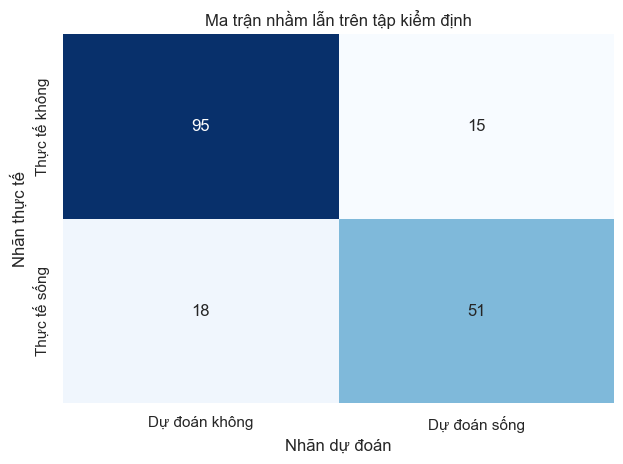

In [ ]:
confusion = confusion_matrix(y_valid, valid_predictions)
sns.heatmap(confusion, annot = True, fmt = "d", cmap = "Blues", cbar = False,
            xticklabels = ["Dự đoán không", "Dự đoán sống"],
            yticklabels = ["Thực tế không", "Thực tế sống"])
plt.title("Ma trận nhầm lẫn trên tập kiểm định")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.tight_layout()
plt.show()

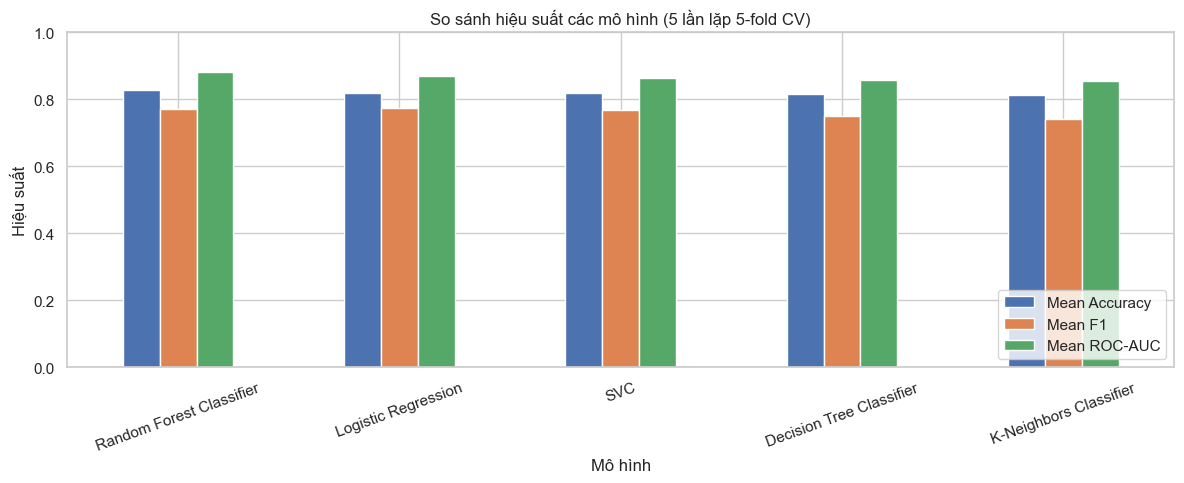

In [ ]:
cv_results.set_index("Model")[["Mean Accuracy", "Mean F1", "Mean ROC-AUC"]].plot(
    kind = "bar", figsize = (12, 5), ylim = (0, 1), rot = 20
)

plt.title("So sánh hiệu suất các mô hình (5 lần lặp 5-fold CV)")
plt.ylabel("Hiệu suất")
plt.xlabel("Mô hình")
plt.legend(loc = "lower right")

plt.tight_layout()
plt.show()

---
## **6. Huấn luyện trên toàn bộ train và tạo submission**

Sau khi đánh giá, huấn luyện lại pipeline đã tinh chỉnh trên toàn bộ dữ liệu có nhãn. Tạo dự đoán nhị phân cho `test.csv` và lưu hai cột theo định dạng Kaggle vào `data/submission.csv`.

In [ ]:
best_model.fit(X, y)
test_probabilities = best_model.predict_proba(X_test_final)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions,
})
submission_path = DATA_DIR / "submission.csv"
submission.to_csv(submission_path, index = False)

print(f"Đã lưu {submission_path} với {len(submission)} dự đoán.")
print("Tỷ lệ dự đoán sống sót:", round(submission["Survived"].mean(), 3))
display(submission.head())

Đã lưu data\submission.csv với 418 dự đoán.
Tỷ lệ dự đoán sống sót: 0.4


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


---
## **7. Tổng kết**

Quy trình đã khảo sát dữ liệu Titanic, tạo thêm đặc trưng, so sánh mô hình bằng kiểm định chéo phân tầng và tinh chỉnh siêu tham số. Mô hình được chọn dựa trên kết quả kiểm định chéo, sau đó đánh giá trên một tập kiểm định tách riêng trước khi huấn luyện lại bằng toàn bộ dữ liệu có nhãn.

### **Kết quả trên Kaggle**

Tệp dự đoán đã nộp đạt điểm **0.75837** trên Kaggle, tương đương **75.837%** theo thang Accuracy của cuộc thi Titanic. Đây là kết quả thực tế trên tập kiểm tra ẩn của Kaggle, khác với các chỉ số kiểm định chéo và tập holdout nội bộ được tính từ dữ liệu huấn luyện.

Điểm Kaggle thấp hơn kết quả đánh giá nội bộ cho thấy mô hình tổng quát hóa chưa tốt như ước lượng trong quá trình phát triển. Bộ dữ liệu có quy mô nhỏ, nên việc chia dữ liệu và các dự đoán sai ở một số ít hành khách cũng có thể làm thay đổi điểm số đáng kể. Vì vậy, không nên xem kết quả kiểm định nội bộ là cam kết cho điểm trên tập dữ liệu ẩn.

### **Kết luận**

Mô hình hiện tại tạo được tệp nộp hợp lệ và đạt **0.75837** trên Kaggle. Có thể tiếp tục cải thiện bằng cách kiểm tra các dự đoán sai, đánh giá đặc trưng mới bằng kiểm định chéo và so sánh nhiều cấu hình trên cùng một quy trình đánh giá; chỉ dùng điểm Kaggle cuối cùng để xác nhận hiệu quả trên dữ liệu ẩn.

# <center>**HẾT**<center>